
# Análise RFM

**Objetivo:** realizar análises descritivas e segmentação a partir de uma base já com as colunas R, F, M e scores calculados.  
Este notebook foi criado para ler o arquivo `rfm_final.txt` no caminho especificado pelo usuário e produzir tabelas, validações, estatísticas por segmento, visualizações e arquivos de saída.  
**Observação:** o notebook assume que os campos presentes no arquivo são: `id_cliente`, `valor_monetario`, `frequencia`, `recencia`, `r_score`, `f_score`, `m_score`, `rfm_score`.  



## 1) Importações e configurações iniciais


In [21]:

# 1.1 Pacotes necessários
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Configurações visuais (sem alterar cores por padrão)
plt.rcParams['figure.figsize'] = (10,5)
plt.rcParams['axes.grid'] = True
sns.set_style('whitegrid')



## 2) Local do arquivo
Altere `input_path` apenas se o arquivo estiver em outro local. O notebook tentará carregar `rfm_final.txt` neste caminho. Não modifique o nome do arquivo a menos que tenha certeza.


In [22]:
# Caminho do arquivo fornecido pelo usuário
input_path = r"outputs\rfm_final.csv"

# Caminho alternativo relativo (caso queira colocar o arquivo na mesma pasta do notebook)
input_path_local = Path('rfm_final.csv')

print('Verificando caminhos...')
print('Caminho usuário:', input_path)



Verificando caminhos...
Caminho usuário: outputs\rfm_final.csv


## 3) Carregamento do arquivo

In [23]:
df = pd.read_csv(input_path)
df.describe()

,valor_monetario,frequencia,recencia,r_score,f_score,m_score,rfm_score
count,552250.000000,552250.000000,552250.000000,552250.000000,552250.000000,552250.000000,552250.000000
mean,110.291330,2.367964,60.536494,3.012639,3.000000,3.000000,334.263920
std,64.631457,1.969499,60.002634,1.422789,1.414215,1.414215,142.982691
min,15.000000,0.100000,1.000000,1.000000,1.000000,1.000000,111.000000
25%,60.460000,0.900000,18.000000,2.000000,2.000000,2.000000,222.000000
50%,94.110000,1.800000,42.000000,3.000000,3.000000,3.000000,333.000000
75%,144.920000,3.200000,84.000000,4.000000,4.000000,4.000000,445.000000
max,307.890000,12.000000,782.000000,5.000000,5.000000,5.000000,555.000000



## 4) Validações iniciais
- Verificações básicas de integridade: duplicidade de `id_cliente`, tipos das colunas e contagem de valores faltantes.


In [1]:
# 4.5 Validar consistência do rfm_score (versão robusta)

# Garantir scores como string sem .0, espaços ou NA
for c in ['r_score', 'f_score', 'm_score']:
    df[c] = df[c].astype('Int64')

# Recalcular rfm_score apenas onde não há NA
mask_valid = df[['r_score','f_score','m_score']].notna().all(axis=1)

rfm_recalc = (
    df.loc[mask_valid, 'r_score'].astype(str).str.strip() +
    df.loc[mask_valid, 'f_score'].astype(str).str.strip() +
    df.loc[mask_valid, 'm_score'].astype(str).str.strip()
)

# Normalizar rfm_score original
df.loc[mask_valid, 'rfm_score'] = (
    df.loc[mask_valid, 'rfm_score']
      .astype(str)
      .str.strip()
)

# Comparar apenas linhas válidas
diff = df.loc[mask_valid, 'rfm_score'] != rfm_recalc

if diff.any():
    print("⚠️ Inconsistências encontradas em rfm_score:")
    display(
        df.loc[mask_valid]
          .loc[diff, ['r_score','f_score','m_score','rfm_score']]
          .head(10)
    )
else:
    print("rfm_score consistente com r_score + f_score + m_score")


NameError: name 'df' is not defined

In [25]:
# 4.1 Checar duplicados
dup_count = df['id_cliente'].duplicated().sum()
print(f'IDs duplicados: {dup_count}')

# 4.2 Conferir tipos e valores ausentes
print('\nTipos das colunas:')
print(df.dtypes)

print('\nContagem de valores ausentes por coluna:')
print(df.isnull().sum())

# 4.3 Se houver IDs duplicados, mostrar primeiros para análise
if dup_count > 0:
    display(
        df[df['id_cliente'].duplicated(keep=False)]
        .sort_values('id_cliente')
        .head(20)
    )

# 4.4 Validar range dos scores (1 a 5)
for c in ['r_score', 'f_score', 'm_score']:
    min_val, max_val = df[c].min(), df[c].max()
    print(f'{c}: min={min_val}, max={max_val}')
    assert min_val >= 1 and max_val <= 5, f'{c} fora do range esperado (1–5)'

# 4.5 Validar consistência do rfm_score
rfm_recalc = (
    df['r_score'].astype(str) +
    df['f_score'].astype(str) +
    df['m_score'].astype(str)
)

assert (df['rfm_score'] == rfm_recalc).all(), \
    'Inconsistência entre rfm_score e scores individuais'

print('\nValidações de RFM concluídas com sucesso.')


IDs duplicados: 0

Tipos das colunas:
id_cliente          object
valor_monetario    float64
frequencia         float64
recencia             int64
r_score              Int64
f_score              Int64
m_score              Int64
rfm_score           object
dtype: object

Contagem de valores ausentes por coluna:
id_cliente         0
valor_monetario    0
frequencia         0
recencia           0
r_score            0
f_score            0
m_score            0
rfm_score          0
dtype: int64
r_score: min=1, max=5
f_score: min=1, max=5
m_score: min=1, max=5

Validações de RFM concluídas com sucesso.


### interpretação dos Resultados

Dados de formato correto, sem nulos e range dos scores (1-5) corretos 

## 5) Preparação da Base RFM (colunas já existentes)

Nesta etapa, são garantidos os tipos de dados corretos e criadas colunas auxiliares,
quando aplicável (por exemplo, ticket médio). Como os scores R, F e M já estão
disponíveis na base, não é realizado o recálculo das notas, sendo utilizados
diretamente os campos `r_score`, `f_score`, `m_score` e `rfm_score`.



In [26]:
# Converter tipos
df['valor_monetario'] = pd.to_numeric(df['valor_monetario'], errors='coerce')
df['frequencia'] = pd.to_numeric(df['frequencia'], errors='coerce')
df['recencia'] = pd.to_numeric(df['recencia'], errors='coerce')

df['r_score'] = pd.to_numeric(df['r_score'], errors='coerce').astype('Int64')
df['f_score'] = pd.to_numeric(df['f_score'], errors='coerce').astype('Int64')
df['m_score'] = pd.to_numeric(df['m_score'], errors='coerce').astype('Int64')

# Garantir rfm_score como string
df['rfm_score'] = df['rfm_score'].astype(str)

# Gasto mensal estimado
df['gasto_mensal_estimado'] = df['valor_monetario'] * df['frequencia']

# Ticket médio
# Caso frequência seja zero (situação não observada atualmente), o valor é definido como NaN
df['ticket_medio'] = np.where(
    df['frequencia'] > 0,
    df['valor_monetario'] / df['frequencia'],
    np.nan
)

# Estatísticas descritivas iniciais
display(
    df[['valor_monetario', 'frequencia', 'recencia', 'ticket_medio', 'gasto_mensal_estimado']]
    .describe()
    .round(2)
)


,valor_monetario,frequencia,recencia,ticket_medio,gasto_mensal_estimado
count,552250.00,552250.00,552250.00,552250.00,552250.00
mean,110.29,2.37,60.54,122.48,249.15
std,64.63,1.97,60.00,231.36,266.17
min,15.00,0.10,1.00,1.25,1.50
25%,60.46,0.90,18.00,25.35,78.16
50%,94.11,1.80,42.00,53.59,166.26
75%,144.92,3.20,84.00,119.54,323.04
max,307.89,12.00,782.00,3077.60,3673.56


### Cálculo do Ticket Médio

O ticket médio foi calculado como a razão entre o valor monetário e a frequência de compras.
A análise estatística da base confirmou a ausência de valores nulos ou iguais a zero na
variável **frequência**, o que garante que a divisão por zero não ocorre no cenário atual.

Ainda assim, foi implementado um mecanismo de segurança no código para lidar com eventuais
casos futuros de frequência igual a zero, atribuindo **NaN** ao ticket médio nesses casos.
Essa abordagem preserva a integridade dos dados e evita a introdução de valores artificiais
ou distorções nas métricas derivadas.



## 6) Mapeamento de segmentos baseado em R, F e M (usando scores já calculados)
Atribuímos segmentos heurísticos (Champions, Loyal, Potential Loyalists, Recent, Promising, At Risk, Can't Lose, Hibernating, Others) usando regras inspiradas na literatura. Esses rótulos são para fins de priorização de ações.


In [27]:
# ============================================
#  Tabela de ranges (mínimo e máximo) por score R, F e M — sem índice
# ============================================


# 1) Criar coluna MF_score = média entre F_score e M_score
df['MF_score'] = (df['f_score'] + df['m_score']) / 2

def score_range_table(df, value_col, score_col, score_name):
    """
    Gera uma tabela com os valores mínimo e máximo de uma métrica
    associada a cada score RFM.

    Parâmetros
    ----------
    df : pandas.DataFrame
        DataFrame contendo os dados RFM.
    value_col : str
        Nome da coluna com os valores numéricos (ex.: recência, frequência, valor monetário).
    score_col : str
        Nome da coluna de score associada (ex.: r_score, f_score, m_score).
    score_name : str
        Nome base do score para rotulagem da saída.

    Retorna
    -------
    pandas.DataFrame
        DataFrame com o score e os respectivos valores mínimo e máximo.
    """

    ranges = (
        df.groupby(score_col)[value_col]
          .agg(['min', 'max'])
          .reset_index()  # garante score como coluna e remove índice antigo
          .rename(columns={
              score_col: f'{score_name}_score',
              'min': f'min',
              'max': f'max'
          })
    )
    return ranges


# Criar as três tabelas
recencia_range = score_range_table(df, 'recencia', 'r_score', 'Recencia')
frequencia_range = score_range_table(df, 'frequencia', 'f_score', 'Frequencia')
monetario_range = score_range_table(df, 'valor_monetario', 'm_score', 'Monetario')

# Exibir sem índice visual
print("=== Ranges de Recência (dias) por Score ===")
display(recencia_range.style.hide(axis='index'))

print("=== Ranges de Frequência por Score ===")
display(frequencia_range.style.hide(axis='index'))

print("=== Ranges de Valor Monetário por Score ===")
display(monetario_range.style.hide(axis='index'))


=== Ranges de Recência (dias) por Score ===


Recencia_score,min,max
1,98,782
2,56,97
3,32,55
4,15,31
5,1,14


=== Ranges de Frequência por Score ===


Frequencia_score,min,max
1,0.100000,0.800000
2,0.800000,1.400000
3,1.400000,2.300000
4,2.300000,3.700000
5,3.700000,12.000000


=== Ranges de Valor Monetário por Score ===


Monetario_score,min,max
1,15.000000,54.490000
2,54.490000,79.990000
3,79.990000,110.280000
4,110.290000,161.060000
5,161.060000,307.890000


# Tabela de Ranges por Score (R, F, M)

| Variável          | Score 1      | Score 2      | Score 3      | Score 4      | Score 5      |
|-------------------|--------------|--------------|--------------|--------------|--------------|
| **Recência (ultima compra em dias)** | 98 – 782     | 57 – 97       | 32 – 56       | 15 – 31       | 1 – 14        |
| **Valor Monetário (R$)** | 15.00 – 54.23 | 54.23 – 79.51 | 79.51 – 109.65 | 109.65 – 160.21 | 160.21 – 307.99         |
| **Frequência (compras média)**      | 0.1 – 0.8    | 0.8 – 1.4     | 1.4 – 2.3     | 2.3 – 3.6     | 3.6 – 12       |


### Uso do MF_score (Média entre Frequência e Valor Monetário)

Na construção da matriz RFM consolidada, os scores de Frequência (F) e Valor
Monetário (M) foram combinados em um único indicador, denominado **MF_score**,
calculado como a média aritmética entre ambos.

Essa abordagem é amplamente adotada em aplicações práticas de RFM, nas quais
as métricas de Frequência e Valor Monetário são interpretadas de forma conjunta
como indicadores da intensidade e do valor do relacionamento do cliente, enquanto
a Recência representa a atualidade da interação.

A combinação de F e M em um único eixo permite reduzir a dimensionalidade da
análise, facilitando a construção de matrizes RFM bidimensionais mais
interpretáveis e acionáveis, sem perda conceitual relevante.

Essa estratégia está alinhada com a literatura clássica de marketing analítico
e CRM, que enfatiza o uso de segmentações simples, explicáveis e orientadas à
tomada de decisão.

**Referência**

HUGHES, Arthur M. *Strategic Database Marketing*. 2. ed. New York: McGraw-Hill, 1994.


## 7) Classificação dos Clientes na Matriz RFM Consolidada

Nesta etapa, os clientes são segmentados com base na **matriz RFM consolidada**,
utilizando a combinação entre **Recência (R_score)** e **MF_score** (média entre
Frequência e Valor Monetário). A classificação é realizada por meio de regras
heurísticas, resultando na atribuição de rótulos de segmento acionáveis para
análise e tomada de decisão.



In [28]:
# 1) Função de classificação 
def classify_rfm_matrix(r, mf):
    mf = int(round(mf))

    # Linha superior (MF_score = 5)
    if mf == 5:
        if r == 5:
            return "Campeões"
        elif 3 <= r <= 4:
            return "Clientes leais"
        elif r < 3:
            return "Não pode perdê-los"

    # MF_score = 4
    if mf == 4:
        if 3 <= r <= 5:
            return "Clientes leais"
        elif r <= 2:
            return "Em risco"

    # MF_score = 3
    if mf == 3:
        if 4 <= r <= 5:
            return "Potenciais Clientes leais"
        elif r == 3:
            return "Precisam de atenção"
        elif r <= 2:
            return "Em risco"

    # MF_score = 2
    if mf == 2:
        if 4 <= r <= 5:
            return "Potenciais Clientes leais"
        elif r == 3:
            return "Prestes a dormir"
        elif r == 2:
            return "Hibernando"
        elif r == 1:
            return "Perdidos"

    # MF_score = 1
    if mf == 1:
        if r == 5:
            return "Clientes recentes"
        elif r == 4:
            return "Promissores"
        elif r == 3:
            return "Prestes a dormir"
        elif 1 <= r <= 2:
            return "Perdidos"

    return "Outros"


# 2) Aplicar segmentação
df['segment_matriz'] = df.apply(lambda r: classify_rfm_matrix(r['r_score'], r['MF_score']), axis=1)


### Tipos de Segmentos, explicação e regras

| Segmento                  | Descrição                                                     | Regra (R_score × MF_score)                              |
|---------------------------|-----------------------------------------------------------------|----------------------------------------------------------|
| **Campeões**              | Clientes muito recentes, com alta frequência e alto valor.      | R_score = 5 e MF_score ≥ 4                               |
| **Clientes fiéis**        | Compram com frequência e bom valor, mantendo relação estável.   | R_score ∈ {3,4} e MF_score ≥ 4                           |
| **Lealdade potencial**    | Clientes recentes com potencial de evolução em valor e frequência. | R_score ∈ {4,5} e MF_score = 3                           |
| **Clientes recentes**     | Compraram recentemente, mas ainda com baixo engajamento.        | R_score = 5 e MF_score ≤ 2                               |
| **Promissores**           | Clientes relativamente recentes, com engajamento inicial.       | R_score = 4 e MF_score ≤ 2                               |
| **Precisam de atenção**   | Indicadores intermediários, exigem estímulo ao relacionamento.  | R_score = 3 e MF_score = 3                               |
| **Prestes a hibernar**    | Queda de engajamento recente, com risco de inatividade.         | R_score = 3 e MF_score ≤ 2                               |
| **Em risco**              | Bom histórico de valor e frequência, mas baixa recência.        | R_score ∈ {1,2} e MF_score = 3                           |
| **Não se pode perdê-los** | Clientes de alto valor histórico que deixaram de comprar.       | R_score ∈ {1,2} e MF_score ≥ 4                           |
| **Hibernando**            | Baixa frequência, baixo valor e baixa recência.                 | R_score = 2 e MF_score ≤ 2                               |
| **Perdidos**              | Menores scores combinados nas dimensões RFM.                    | R_score = 1 e MF_score ≤ 2                               |


## 8) Consolidação dos Indicadores Financeiros por Segmento RFM

Nesta etapa, são agregados os principais indicadores de negócio por segmento
definido na matriz RFM, incluindo **quantidade de clientes**, **gasto total**,
**gasto mensal estimado** e **ticket médio**. O objetivo é comparar o peso e o
valor relativo de cada segmento, apoiando análises estratégicas e priorização
de ações comerciais.


In [29]:
segment_summary = (
    df.groupby('segment_matriz')
      .agg(
          qtd=('id_cliente', 'count'),
          gasto_mensal_estimado=('gasto_mensal_estimado', 'sum'),
          total_gasto=('valor_monetario', 'sum'),
          ticket_medio=('ticket_medio', 'mean')
      )
      .reset_index()
)

# Total de clientes
total_clientes = segment_summary['qtd'].sum()

# Percentual de clientes por segmento
segment_summary['pct_clientes'] = (
    segment_summary['qtd'] / total_clientes * 100
).round(2)

# Arredondar ticket médio
segment_summary['ticket_medio'] = segment_summary['ticket_medio'].round(2)

# Ordenar por quantidade
segment_summary = segment_summary.sort_values(by="qtd", ascending=False)

# Função para formatar como moeda brasileira
def format_brl(x):
    return f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

segment_summary['gasto_mensal_estimado'] = segment_summary['gasto_mensal_estimado'].apply(format_brl)
segment_summary['total_gasto'] = segment_summary['total_gasto'].apply(format_brl)
segment_summary['ticket_medio'] = segment_summary['ticket_medio'].apply(format_brl)

display(segment_summary)


,segment_matriz,qtd,gasto_mensal_estimado,total_gasto,ticket_medio,pct_clientes
3,Em risco,128051,"R$ 40.821.166,60","R$ 16.805.116,67","R$ 114,30",23.19
7,Potenciais Clientes leais,127680,"R$ 14.156.381,62","R$ 11.057.482,76","R$ 158,18",23.12
1,Clientes leais,126375,"R$ 57.053.140,70","R$ 18.832.361,97","R$ 68,33",22.88
6,Perdidos,46325,"R$ 3.059.193,47","R$ 3.143.286,24","R$ 141,37",8.39
9,Prestes a dormir,42302,"R$ 2.965.126,66","R$ 2.967.746,03","R$ 141,70",7.66
4,Hibernando,39374,"R$ 2.936.806,59","R$ 2.861.711,45","R$ 142,28",7.13
8,Precisam de atenção,23919,"R$ 4.026.119,92","R$ 2.613.087,52","R$ 191,03",4.33
5,Não pode perdê-los,7072,"R$ 8.117.829,18","R$ 1.518.356,33","R$ 43,13",1.28
0,Campeões,3729,"R$ 4.319.562,66","R$ 802.384,91","R$ 43,00",0.68
2,Clientes recentes,3714,"R$ 67.601,74","R$ 153.070,98","R$ 134,35",0.67


### Variáveis adicionadas à análise

| Variável | Descrição |
|---------|-----------|
| **gasto_mensal_estimado** | Estimativa do gasto mensal do cliente. Foi calculado multiplicando o valor monetário total pelo número de compras, indicando quanto ele tende a gastar em um ciclo médio. |
| **total_gasto** | Soma de todos os valores monetários gastos pelos clientes dentro de cada segmento. Ajuda a identificar os segmentos mais valiosos financeiramente. |
| **ticket_medio** | Representa o valor médio gasto por transação, calculado dividindo o valor monetário pela frequência. Segmentos com ticket médio elevado tendem a ter maior valor agregado por compra. |


## 9) Visualização da Matriz RFM Consolidada (Recência × MF_score)

Nesta etapa, é construída a **matriz RFM consolidada**, representando graficamente
a relação entre **Recência (R_score)** e **MF_score** (média entre Frequência e
Valor Monetário). Cada bloco da matriz corresponde a um segmento de clientes,
dimensionado conforme os limites dos scores e anotado com a quantidade e o
percentual de clientes, permitindo uma leitura visual clara da distribuição e
relevância de cada segmento.


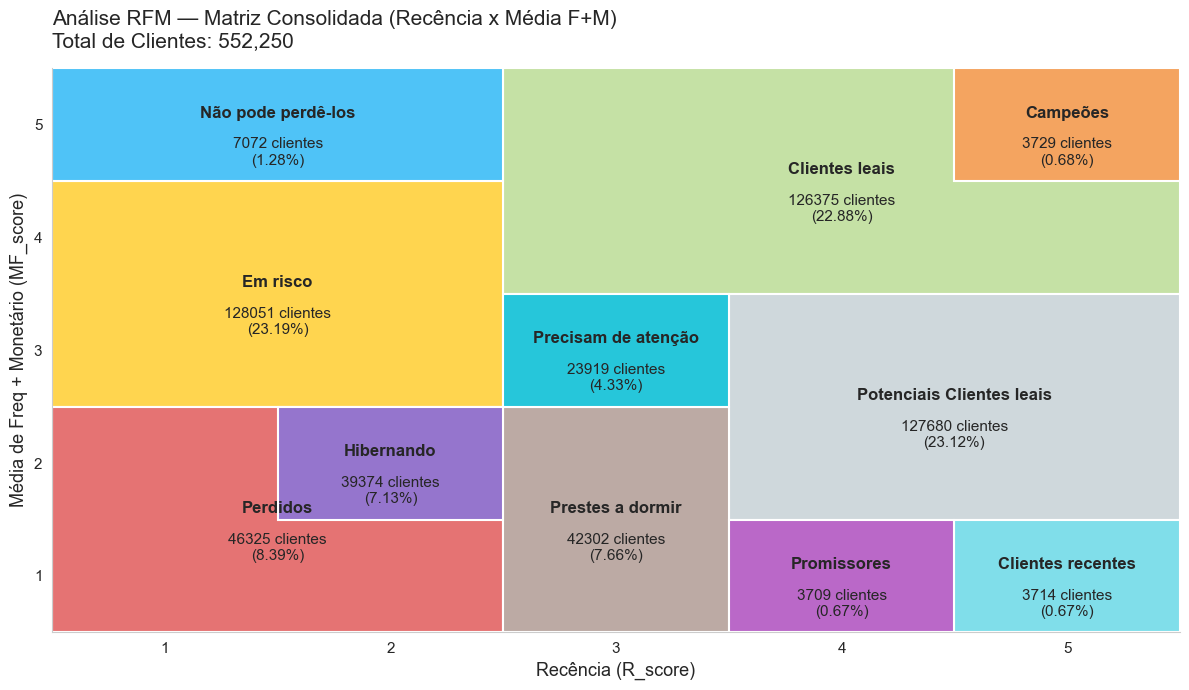

In [30]:

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Calcular MF_score arredondado
df['MF_score'] = ((df['f_score'] + df['m_score']) / 2).round().astype(int)

# Consolidar limites por segmento
seg_bounds = (
    df.groupby('segment_matriz')
      .agg(
          r_min=('r_score', 'min'),
          r_max=('r_score', 'max'),
          mf_min=('MF_score', 'min'),
          mf_max=('MF_score', 'max'),
          qtd=('id_cliente', 'count')
      )
      .reset_index()
)

total_clientes = df.shape[0]
seg_bounds['percent'] = (seg_bounds['qtd'] / total_clientes * 100).round(2)

# Paleta fixa (correta)
colors = {
    "Campeões": "#F4A460",
    "Clientes leais": "#C5E1A5",
    "Não pode perdê-los": "#4FC3F7",
    "Em risco": "#FFD54F",
    "Precisam de atenção": "#26C6DA",
    "Potenciais clientes leais": "#A1887F",
    "Clientes recentes": "#80DEEA",
    "Promissores": "#BA68C8",
    "Prestes a dormir": "#BCAAA4",
    "Hibernando": "#9575CD",
    "Perdidos": "#E57373",
    "Outros": "#CFD8DC"
}

# ORDEM CORRETA: desenhar primeiro blocos grandes (maior área)
# Para isso vamos ordenar por qtd (de menor para maior) → pequenos por cima
seg_bounds["area"] = (seg_bounds["r_max"] - seg_bounds["r_min"] + 1) * (seg_bounds["mf_max"] - seg_bounds["mf_min"] + 1)

seg_bounds_sorted = seg_bounds.sort_values(by=["area", "qtd"], ascending=False)

# Criar figura
fig, ax = plt.subplots(figsize=(12, 7))

for _, row in seg_bounds_sorted.iterrows():
    
    seg = row['segment_matriz']
    xmin = row['r_min'] - 1
    xmax = row['r_max']
    ymin = row['mf_min'] - 1
    ymax = row['mf_max']
    
    width = xmax - xmin
    height = ymax - ymin
    
    qtd = row['qtd']
    perc = row['percent']
    
    color = colors.get(seg, "#CFD8DC")
    
    # Desenha o bloco
    rect = Rectangle(
        (xmin, ymin), width, height,
        edgecolor="white", linewidth=1.5,
        facecolor=color
    )
    ax.add_patch(rect)

    # Texto centralizado
    ax.text(
        xmin + width/2,
        ymin + height/2 + 0.10,
        seg,
        ha="center", va="center",
        fontsize=12, fontweight="bold"
    )
    
    ax.text(
        xmin + width/2,
        ymin + height/2 - 0.25,
        f"{qtd} clientes\n({perc}%)",
        ha="center", va="center",
        fontsize=11
    )

# Ajuste de eixos
ax.set_xticks([0.5,1.5,2.5,3.5,4.5])
ax.set_xticklabels([1,2,3,4,5], fontsize=11)
ax.set_yticks([0.5,1.5,2.5,3.5,4.5])

ax.set_yticklabels([1,2,3,4,5], fontsize=11)
ax.set_xlabel("Recência (R_score)", fontsize=13)
ax.set_ylabel("Média de Freq + Monetário (MF_score)", fontsize=13)

ax.set_xlim(0,5)
ax.set_ylim(0,5)

for spine in ["top","right"]:
    ax.spines[spine].set_visible(False)

ax.set_title(
    f"Análise RFM — Matriz Consolidada (Recência x Média F+M)\nTotal de Clientes: {total_clientes:,}",
    fontsize=15, loc="left", pad=15
)

plt.tight_layout()
plt.show()

### Interpretação da Matriz RFM Consolidada (Recência × MF_score)

A matriz RFM evidencia diferenças claras de valor e engajamento entre os segmentos
de clientes. Os segmentos posicionados no **canto superior direito** da matriz
(**alta recência e alto MF_score**) concentram os clientes mais valiosos, pois
combinam compras recentes com elevada frequência e/ou alto valor monetário.
Esses clientes demandam estratégias de retenção e fidelização prioritárias.

À medida que se avança para a **esquerda da matriz**, observa-se a redução da
recência, indicando clientes que possuem histórico relevante de compras, mas
que não interagem recentemente com a empresa. Segmentos como **“Em risco”** e
**“Não pode perdê-los”** representam oportunidades críticas de reativação, uma
vez que concentram volume expressivo de clientes e valor histórico.

Os segmentos localizados na **parte inferior da matriz** apresentam baixo
MF_score, caracterizando clientes com menor frequência e menor valor monetário.
Nesses casos, a recência diferencia clientes **recentes e promissores** daqueles
em **processo de hibernação ou perda**, orientando ações distintas entre
estimulação de engajamento inicial e campanhas de baixo custo ou descontinuação.

De forma geral, a matriz consolida a segmentação RFM em um formato visual
interpretável e acionável, permitindo priorizar estratégias de **retenção,
reativação e desenvolvimento de relacionamento** conforme o perfil de cada
segmento.


## 10) Distribuição de Clientes por Segmento RFM

Nesta etapa, é apresentada a distribuição da base de clientes entre os segmentos
definidos na matriz RFM, por meio de um gráfico de barras. A visualização permite
comparar o volume relativo de clientes em cada segmento, auxiliando na
identificação de grupos prioritários do ponto de vista estratégico.


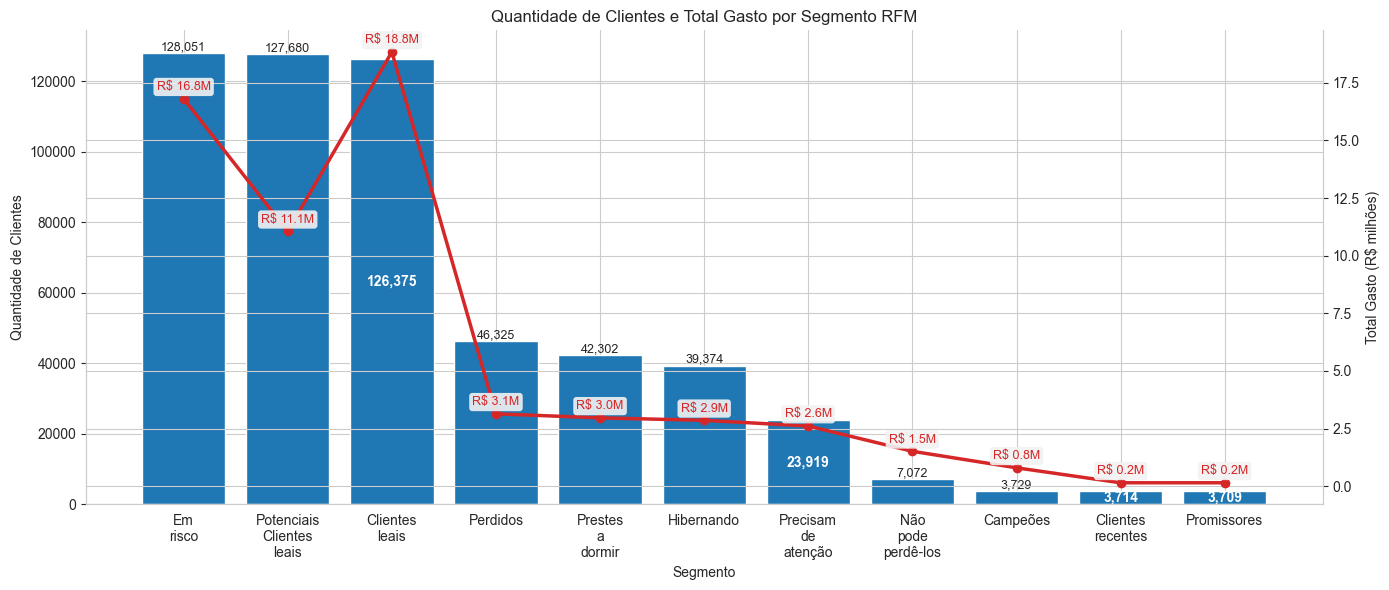

In [38]:
# Agregação para o gráfico
segment_plot = (
    df.groupby('segment_matriz')
      .agg(
          qtd_clientes=('id_cliente', 'count'),
          total_gasto=('valor_monetario', 'sum')
      )
      .reset_index()
      .sort_values('qtd_clientes', ascending=False)
)

segment_plot['total_gasto_milhoes'] = segment_plot['total_gasto'] / 1_000_000

# Segmentos que terão número dentro da barra
segments_inner_label = {
    'Clientes leais',
    'Precisam de atenção',
    'Clientes recentes',
    'Promissores'
}

# Criar figura
fig, ax1 = plt.subplots(figsize=(14,6))

# --- Barras: Quantidade de clientes ---
bars = ax1.bar(
    segment_plot['segment_matriz'],
    segment_plot['qtd_clientes'],
    color='#1f77b4'
)

ax1.set_ylabel("Quantidade de Clientes")
ax1.set_xlabel("Segmento")
ax1.set_title("Quantidade de Clientes e Total Gasto por Segmento RFM")

# Rótulos de quantidade
for bar, seg in zip(bars, segment_plot['segment_matriz']):
    height = bar.get_height()
    
    if seg in segments_inner_label:
        # Texto no meio da barra
        ax1.text(
            bar.get_x() + bar.get_width()/2,
            height / 2,
            f'{int(height):,}',
            ha='center',
            va='center',
            fontsize=10,
            color='white',
            fontweight='bold'
        )
    else:
        # Texto acima da barra
        ax1.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f'{int(height):,}',
            ha='center',
            va='bottom',
            fontsize=9
        )

# --- Linha: Total gasto (cor diferente) ---
ax2 = ax1.twinx()
ax2.plot(
    segment_plot['segment_matriz'],
    segment_plot['total_gasto_milhoes'],
    color='#d62728',        # vermelho (contraste)
    marker='o',
    linewidth=2.5
)

ax2.set_ylabel("Total Gasto (R$ milhões)")

# Rótulos da linha com fundo para melhor visualização
for x, y in zip(segment_plot['segment_matriz'], segment_plot['total_gasto_milhoes']):
    ax2.text(
        x,
        y + 0.25,
        f'R$ {y:.1f}M',
        ha='center',
        va='bottom',
        fontsize=9,
        color='#d62728',
        bbox=dict(
            boxstyle='round,pad=0.25',
            facecolor='#F2F2F2',
            edgecolor='none',
            alpha=0.9
        )
    )


# Ajuste do eixo X (quebra de linha para legibilidade)
ax1.set_xticks(range(len(segment_plot)))
ax1.set_xticklabels(
    [s.replace(" ", "\n") for s in segment_plot['segment_matriz']],
    fontsize=10
)

# Limpeza visual
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()


## Interpretação dos Resultados  
Volume de Clientes × Gasto Total por Segmento (RFM)

A análise conjunta da quantidade de clientes por segmento e do gasto total associado permite identificar padrões claros de concentração de valor e escala, resultando em três grandes grupos de comportamento.

---

### 1. Grupo de Alto Volume e Alto Impacto (Grupo Prioritário)

Os segmentos **Em Risco**, **Potenciais Clientes Leais** e **Clientes Leais** concentram o maior volume de clientes da base e representam, de forma agregada, a maior parcela do faturamento total.

Esse agrupamento indica a existência de uma base relevante de clientes recorrentes e em processo de fidelização. Entretanto, a expressiva presença do segmento **Em Risco** evidencia um ponto crítico: clientes com histórico relevante de consumo que apresentam sinais de redução de engajamento.

Do ponto de vista estratégico, este grupo deve ser tratado como prioritário, uma vez que ações de retenção bem direcionadas tendem a gerar impacto financeiro significativo, dado o peso desses segmentos tanto em volume quanto em receita.

---

### 2. Grupo de Volume Intermediário e Receita Moderada

Os segmentos **Perdidos**, **Prestes a Dormir**, **Hibernando** e **Precisam de Atenção** apresentam quantidades intermediárias de clientes e níveis de gasto relativamente próximos entre si.

Esses segmentos compartilham características de baixo engajamento recente, indicando clientes que já tiveram relacionamento com a empresa, mas reduziram frequência e valor ao longo do tempo. Embora o impacto financeiro individual seja inferior ao do grupo prioritário, o volume agregado ainda representa uma parcela relevante da base.

As estratégias para este grupo devem equilibrar custo e retorno, priorizando ações escaláveis, como automações de reativação e campanhas segmentadas, com foco na recuperação parcial do valor potencial desses clientes.

---

### 3. Grupo de Baixo Volume e Valor Estratégico

Os segmentos **Não Pode Perdê-los**, **Campeões**, **Clientes Recentes** e **Promissores** apresentam menor representatividade em volume, porém comportamentos estratégicos distintos.

- **Campeões** e **Não Pode Perdê-los** concentram alto valor individual, apesar do número reduzido de clientes.
- **Clientes Recentes** e **Promissores** representam oportunidades de crescimento futuro, ainda em estágios iniciais de relacionamento.

Esse grupo deve ser analisado sob a ótica de valor estratégico e potencial de longo prazo, demandando abordagens mais personalizadas e direcionadas, em vez de estratégias orientadas à escala.

---

### Síntese da Leitura do Gráfico

- Observa-se forte concentração de clientes e receita em poucos segmentos.
- Há uma separação clara entre segmentos de escala, segmentos de recuperação e segmentos de valor estratégico.
- A priorização das ações deve considerar simultaneamente volume, valor financeiro e estágio de relacionamento, evitando decisões baseadas exclusivamente na quantidade de clientes.

A análise final e as recomendações estratégicas detalhadas por segmento são apresentadas na seção seguinte, evitando redundância nesta etapa de interpretação visual.



## 11) Estatísticas por segmento (numéricas)
Foi gerado  para cada segmento: número de clientes, porcentagem da base, média/mediana/desvio de R, F, M, ticket médio, gasto total.

In [33]:
# Agregação por segmento
agg = (
    df.groupby('segment_matriz')
      .agg(
          n_customers = ('id_cliente','count'),
          pct_base = ('id_cliente', lambda x: 100 * x.count() / df.shape[0]),
          
          mean_R = ('recencia','mean'),
          median_R = ('recencia','median'),
          std_R = ('recencia','std'),
          
          mean_F = ('frequencia','mean'),
          median_F = ('frequencia','median'),
          std_F = ('frequencia','std'),
          
          mean_M = ('valor_monetario','mean'),
          median_M = ('valor_monetario','median'),
          std_M = ('valor_monetario','std'),
          
          total_spend = ('valor_monetario','sum'),
          mean_ticket = ('ticket_medio','mean')
      )
      .reset_index()
)

# Receita total da base
total_revenue = agg['total_spend'].sum()

# Percentual de contribuição na receita
agg['receita_percentual'] = 100 * agg['total_spend'] / total_revenue

# Ordenar por receita
agg = agg.sort_values('total_spend', ascending=False)

# Formatação para exibição
agg_display = agg.copy()
cols_round = [
    'pct_base','receita_percentual',
    'mean_R','median_R','std_R',
    'mean_F','median_F','std_F',
    'mean_M','median_M','std_M',
    'mean_ticket'
]

agg_display[cols_round] = agg_display[cols_round].round(2)

display(agg_display)


,segment_matriz,n_customers,pct_base,mean_R,median_R,std_R,mean_F,median_F,std_F,mean_M,median_M,std_M,total_spend,mean_ticket,receita_percentual
1,Clientes leais,126375,22.88,24.30,23.0,15.46,3.39,2.9,1.98,149.02,136.29,62.21,18832361.97,68.33,30.92
3,Em risco,128051,23.19,115.63,97.0,60.02,3.00,2.5,2.06,131.24,118.78,65.78,16805116.67,114.30,27.59
7,Potenciais Clientes leais,127680,23.12,14.65,14.0,8.90,1.74,1.3,1.61,86.60,73.76,51.19,11057482.76,158.18,18.15
6,Perdidos,46325,8.39,150.89,134.0,61.60,1.12,0.9,0.82,67.85,60.47,31.20,3143286.24,141.37,5.16
9,Prestes a dormir,42302,7.66,42.63,42.0,6.88,1.18,1.0,0.83,70.16,63.93,31.31,2967746.03,141.70,4.87
4,Hibernando,39374,7.13,74.15,73.0,11.95,1.25,1.1,0.83,72.68,67.61,31.34,2861711.45,142.28,4.70
8,Precisam de atenção,23919,4.33,42.64,42.0,6.93,2.53,1.9,2.17,109.25,92.22,67.37,2613087.52,191.03,4.29
5,Não pode perdê-los,7072,1.28,115.07,97.0,58.45,5.35,4.8,1.65,214.70,206.96,39.37,1518356.33,43.13,2.49
0,Campeões,3729,0.68,7.26,7.0,4.04,5.39,4.9,1.69,215.17,207.02,39.16,802384.91,43.00,1.32
10,Promissores,3709,0.67,22.56,22.0,4.81,0.45,0.5,0.20,41.46,43.31,9.45,153782.00,132.46,0.25


## Análise do Ticket Médio por Segmento RFM

O segmento **Clientes Leais** apresenta um ticket médio inferior ao de diversos outros segmentos. Esse comportamento indica que o elevado gasto total desse grupo é explicado principalmente pelo **alto volume de compras**, e não por compras unitárias de maior valor. Trata-se, portanto, de clientes com padrão de consumo recorrente e consistente, cujo valor agregado decorre da frequência ao longo do tempo.

O segmento **Potenciais Clientes Leais** registra o **segundo maior ticket médio** entre os segmentos analisados, evidenciando um grupo que realiza compras de maior valor por transação. Esse comportamento sinaliza uma oportunidade estratégica relevante: ações direcionadas para aumentar a frequência de compra podem acelerar a migração desses clientes para o grupo de **Clientes Leais**, ampliando tanto o ticket médio quanto o valor total gerado.

Os **Campeões** apresentam um dos **menores tickets médios**, apesar de possuírem um dos maiores valores monetários médios. Esse padrão indica clientes com **alta frequência de compra e elevada recência**, cujas transações individuais tendem a ser menores, mas extremamente recorrentes. O valor total gerado por esse segmento é resultado da combinação entre frequência elevada e relacionamento ativo, caracterizando clientes altamente engajados e estratégicos para o negócio.



## 12) Conclusões
 Insights Estratégicos por Segmento (RFM)

## Segmentos com Maior Receita Potencial

### **Clientes Leais — R$ 52.080.449,69 — 116.974 clientes**
Maior motor de receita.  
Ações recomendadas: campanhas de cross-sell e upsell, fidelidade premium, lançamentos antecipados.

### **Em Risco — R$ 36.328.943,60 — 115.642 clientes**
Alto potencial perdido; risco significativo de churn.  
Ações recomendadas: contato consultivo, ofertas personalizadas e diagnóstico de motivos da pausa.

### **Potenciais Clientes Leais — R$ 12.821.395,76 — 116.977 clientes**
Podem migrar para "Leais".  
Ações recomendadas: programa de relacionamento, incentivo à recompra, personalização.

---

## Segmentos Emergentes

### **Precisam de Atenção — R$ 3.766.109,86 — 22.627 clientes**
Frequência e valor médio razoáveis, mas sem compra recente.  
Ações recomendadas: reconexão ativa e campanhas segmentadas.

### **Promissores — R$ 61.165,14 — 3.359 clientes**
Clientes novos e com baixo valor ainda.  
Ações recomendadas: onboarding, 2ª compra assistida e incentivo ao mix.

### **Clientes Recentes — R$ 60.804,19 — 3.379 clientes**
Compraram recentemente, mas com baixa frequência.  
Ações recomendadas: bom pós-venda e benefícios imediatos para recompra.

---

## Segmentos Críticos

### **Perdidos — R$ 2.768.562,98 — 42.308 clientes**
Baixo engajamento e baixo valor.  
Ações recomendadas: automações de reativação e inbound marketing esporádico.

### **Hibernando — R$ 2.576.573,59 — 34.898 clientes**
Compraram há muito tempo e pouco.  
Ações recomendadas: pesquisa e retomada por canais de baixo custo.

---

## Segmentos de Alto Valor Estratégico

### **Não Pode Perdê-los — R$ 7.057.991,40 — 6.247 clientes**
Alta frequência e gasto elevado, porém inativos recentemente.  
Ações recomendadas: contato personalizado e condições exclusivas.

### **Campeões — R$ 3.862.517,55 — 3.384 clientes**
Clientes modelo para definir o ICP empresarial.  
Ações recomendadas: atendimento VIP e feedback antecipado para novos produtos.

---

# **Resumo Executivo**
- Clientes Leais + Em Risco + Potenciais representam 80% da receita potencial.  
- Em Risco deve ser foco absoluto por valor e risco de churn.  
- Precisam de Atenção é um segmento emergente com grande potencial de recuperação.  
- Campeões devem orientar o perfil de cliente ideal.  
- Perdidos e Hibernando exigem automação de baixo custo.


## 13) Exportação de resultados
Exporta `rfm_final_cleaned.csv`, `segment_stats.csv` e um log de execução para a pasta contendo o arquivo de entrada.


In [36]:
from datetime import datetime
from pathlib import Path

# Definir pasta de saída no mesmo diretório do arquivo de entrada
input_file = Path(input_path) if Path(input_path).exists() else Path(input_path_local)
out_dir = input_file.parent if input_file.parent.exists() else Path.cwd()

# -----------------------------
# Exportações
# -----------------------------

# Exportar base final com segmentação
rfm_out_path = out_dir / 'rfm_final_with_segment.csv'
df.to_csv(rfm_out_path, index=False, encoding='utf-8')
print('Arquivo exportado:', rfm_out_path.name)

# Exportar estatísticas por segmento
agg_out_path = out_dir / 'segment_stats.csv'
agg.to_csv(agg_out_path, index=False, encoding='utf-8')
print('Estatísticas exportadas:', agg_out_path.name)

# -----------------------------
# Geração de log enriquecido
# -----------------------------

# Métricas para o log
total_clients = df.shape[0]
n_segments = df['segment_matriz'].nunique()

top_revenue_segment = (
    agg.sort_values('total_spend', ascending=False)
       .iloc[0]
)

log_path = out_dir / 'rfm_exec_log.txt'

with open(log_path, 'w', encoding='utf-8') as f:
    f.write("LOG DE EXECUÇÃO — ANÁLISE RFM\n")
    f.write("=" * 40 + "\n")
    f.write(f"Data/Hora de execução: {datetime.now().isoformat()}\n")
    f.write(f"Arquivo de entrada: {input_file.name}\n\n")

    f.write("Resumo geral:\n")
    f.write(f"- Total de clientes processados: {total_clients:,}\n")
    f.write(f"- Total de segmentos gerados: {n_segments}\n\n")

    f.write("Destaques de receita:\n")
    f.write(
        f"- Segmento com maior receita: {top_revenue_segment['segment_matriz']}\n"
        f"  Receita total: R$ {top_revenue_segment['total_spend']:,.2f}\n"
        f"  Clientes no segmento: {top_revenue_segment['n_customers']:,}\n\n"
    )

    f.write("Arquivos gerados:\n")
    f.write(f"- {rfm_out_path.name}\n")
    f.write(f"- {agg_out_path.name}\n")

print('Log gerado em:', log_path.name)


Arquivo exportado: rfm_final_with_segment.csv
Estatísticas exportadas: segment_stats.csv
Log gerado em: rfm_exec_log.txt
